<h1 align="center">CAMM Hackathon - Session 1</h1>
<p align="left"><em>26 September 2025</em></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KBForgeX/camm_hackathon/blob/k4my4r/docs/regressors/CAMM_Hackathon_1.ipynb)




**Data provenance** : The dataset aggregates measurements from a Dy–Er–Gd–Ho oxide wafer study in the CAMM by the Rack and Page groups


<h3>Goal: Feature → Target Prediction</h3>


This notebook hands you a **clean, standardized dataset** and a minimal prep pipeline so you can build your own predictive models. Your goal is to use the provided **features** (materials/structure descriptors) to **predict a target property** (default: *Thermal Conductivity*). The notebook **stops at data preparation**—you will implement and compare models (e.g., linear models, trees, neural nets) using the prepared data.

**What you’ll find here**
- A tidy table with `x`, `y` wafer coordinates and a set of engineered features (numeric, aligned to the same grid, with units harmonized).
- A simple example showing how to **select a target and features**, coerce to numeric, handle missing values (median imputation), and standardize inputs—ready for modeling.
- You can swap the target and feature lists to explore different prediction tasks.

**What you will do**
- Choose a **target** (e.g., `Thermal Conductivity`) and a subset of **features** you think are predictive.
- Train any models you like (sklearn, PyTorch, etc.) on the **prepared arrays**.
- Report basic metrics (RMSE, MAE, $R^2$) and, if useful, visualize predictions on the wafer grid using `x`, `y`.


#Data Preparation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz
To: /content/ReZrO_data.csv
100% 513k/513k [00:00<00:00, 86.7MB/s]


In [ ]:
path = "/content/ReZrO_data.csv"   # update if path differs
df = pd.read_csv(path)

Let's see what all properties we have in the dataset

In [ ]:
print("Dataframe shape:", df.shape)
display(df.head())


Dataframe shape: (2601, 17)


,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
0,-2.5,-2.5,0.668247,5.245110,0.020399,2.622555,0.103832,3.924187,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
1,-2.5,-2.4,0.651635,5.245110,0.020399,2.622555,0.103727,3.927794,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
2,-2.5,-2.3,0.661063,5.244901,0.019877,2.622450,0.103588,3.939862,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
3,-2.5,-2.2,0.594712,5.244901,0.019877,2.622450,0.103447,3.951859,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
4,-2.5,-2.1,0.620809,5.244680,0.019664,2.622340,0.103338,3.955091,0.127249,5.245217,5.285954,-0.007766,3.028328,2.642977,2.94866,0.095942,0.007499


Let's plot them and see how they look

### Feature Definitions

1. **Lattice Parameter (WPF)**  
   Calculated by fitting the **whole XRD spectrum** using **TOPAS**.

2. **d-spacing (WPF)**  
   Average d-spacing calculated from fitting all peaks.

3. **Δd (SPF–WPF)**  
   Difference between *d-spacing (200 peak)* (2nd XRD peak) and *d-spacing (WPF)*:  
   $$ \Delta d = d_{WPF} - d_{\text{SPF}} $$

4. **delta_d/d**  
   Strain calculated from (2) and (3):  
   $$ \frac{\Delta d}{d} = \frac{d_{WPF} - d_{\text{SPF}}}{d_{\text{WPF}}} $$

5. **a111 (LMFit)**  
   Lattice parameter from fitting the **111 peak** (1st XRD peak) using the **LMFit** package.

6. **a200 (LMFit)**  
   Lattice parameter from fitting the **200 peak** (2nd XRD peak) using **LMFit**.

7. **Mismatch (LMFit – lattice parameter)**  
   $$ \text{Mismatch} = \frac{a_{111} - a_{200}}{a_{111}} $$

8. **d111 (LMFit)**  
   d-spacing of the 111 peak from LMFit.

9. **d200 (LMFit)**  
   d-spacing of the 200 peak from LMFit.

10. **Correlation Length**  
    Calculated from AFM images.

11. **FWHM111 (LMFit)**  
    Full Width at Half Maximum of the **111 peak**.

12. **Strain (LMFit – d-spacing)**  
    Strain calculated using LMFit d-spacing values:  
    $$ \frac{\Delta d}{d}{LMFIT} = \frac{d_{111} - d_{200}}{d_{111}} $$


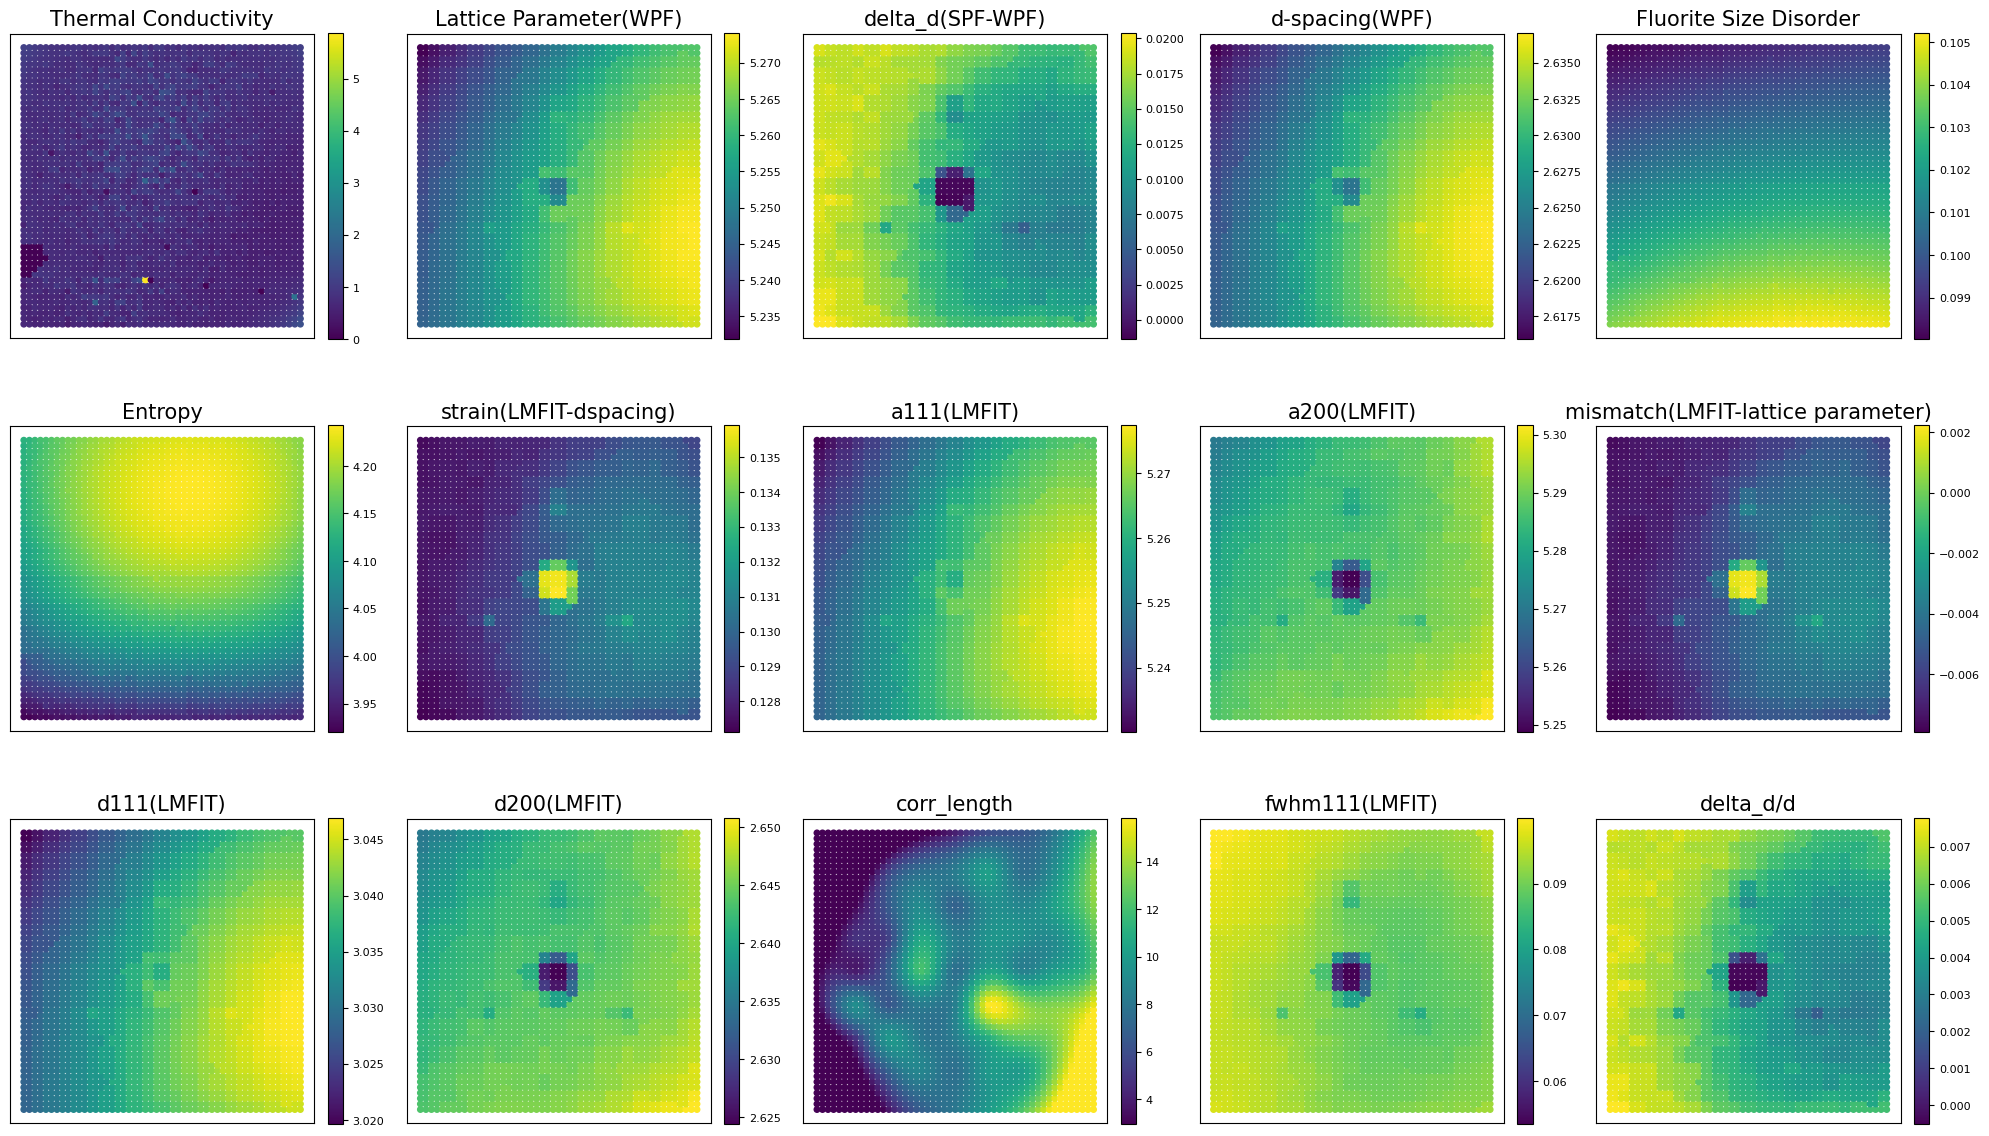

In [ ]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

feature_cols = [c for c in df.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# How to use this to train in networks?

In [ ]:
features = [
    'a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)',
    'Fluorite Size Disorder', 'Entropy',
    'corr_length',
]
target = 'Thermal Conductivity'

missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"These columns are missing in df: {missing}")

In [ ]:
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3.1) drop outlayer in a target
df_clean = df[df[target] <= 3]

# 3) drop rows with missing target
df_clean = df_clean.dropna(subset=[target]).copy()


# 4) build matrices
X_raw = df_clean[features].to_numpy(dtype=np.float32) # Input features
y_raw = df_clean[target].to_numpy(dtype=np.float32)[:, None] #Target feature that needs to be predicted
XY    = df_clean[["x","y"]].to_numpy(dtype=np.float32) if set(["x","y"]).issubset(df_clean.columns) else None # can be used to plot predictions back on the grid


In [ ]:
df[df[target] >= 3]

,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
1130,-0.3,-1.7,5.882814,5.261262,0.012853,2.630631,0.103929,4.052877,0.129431,5.263263,5.290879,-0.005247,3.038746,2.645439,8.066012,0.090556,0.004886


1. Detect and remove outliers (robust methods)

2. Benchmark candidate models to identify the strongest baseline.

3. Tune the top model’s hyperparameters.

4. Use SHAP to rank the most influential features.

5. Retrain on the selected features

# Outliers analysis

In [ ]:
def remove_outliers_robust_scaler(df, target_column, threshold=3.0, max_outlier_features=2):
    """
    Removes rows that contain extreme values (outliers) after RobustScaler normalization.

    Parameters:
        df: pandas DataFrame
        target_column: name of the target variable (excluded from scaling)
        threshold: threshold for scaled values to be considered outliers (e.g., 3.0)
        max_outlier_features: how many features can be extreme before the row is dropped

    Returns:
        df_clean: cleaned DataFrame with outliers removed
        outlier_mask: boolean mask (True = outlier row)
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Apply RobustScaler
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    # Identify outliers: where scaled value exceeds threshold
    abs_scaled = np.abs(X_scaled)
    outlier_flags = abs_scaled > threshold

    # Count how many features are extreme per row
    row_outlier_count = outlier_flags.sum(axis=1)

    # Identify rows to drop (too many outlier features)
    rows_to_drop = row_outlier_count > max_outlier_features
    n_dropped = rows_to_drop.sum()

    # Keep rows that are not outliers
    df_clean = df.loc[~rows_to_drop].reset_index(drop=True)

    print(f"🧹 Removed {n_dropped} rows with > {max_outlier_features} outlier features (RobustScaler threshold = {threshold})")
    return df_clean, rows_to_drop


In [ ]:
df_clean1, rows_to_drop = remove_outliers_robust_scaler(df_clean, target, threshold=2, max_outlier_features=2)

🧹 Removed 47 rows with > 2 outlier features (RobustScaler threshold = 2)


In [ ]:
print(f'Before: {df_clean1.shape}')
print(f'After: {df_clean.shape}')

Before: (2553, 17)
After: (2600, 17)


In [ ]:
dropped_rows = df_clean.loc[rows_to_drop]

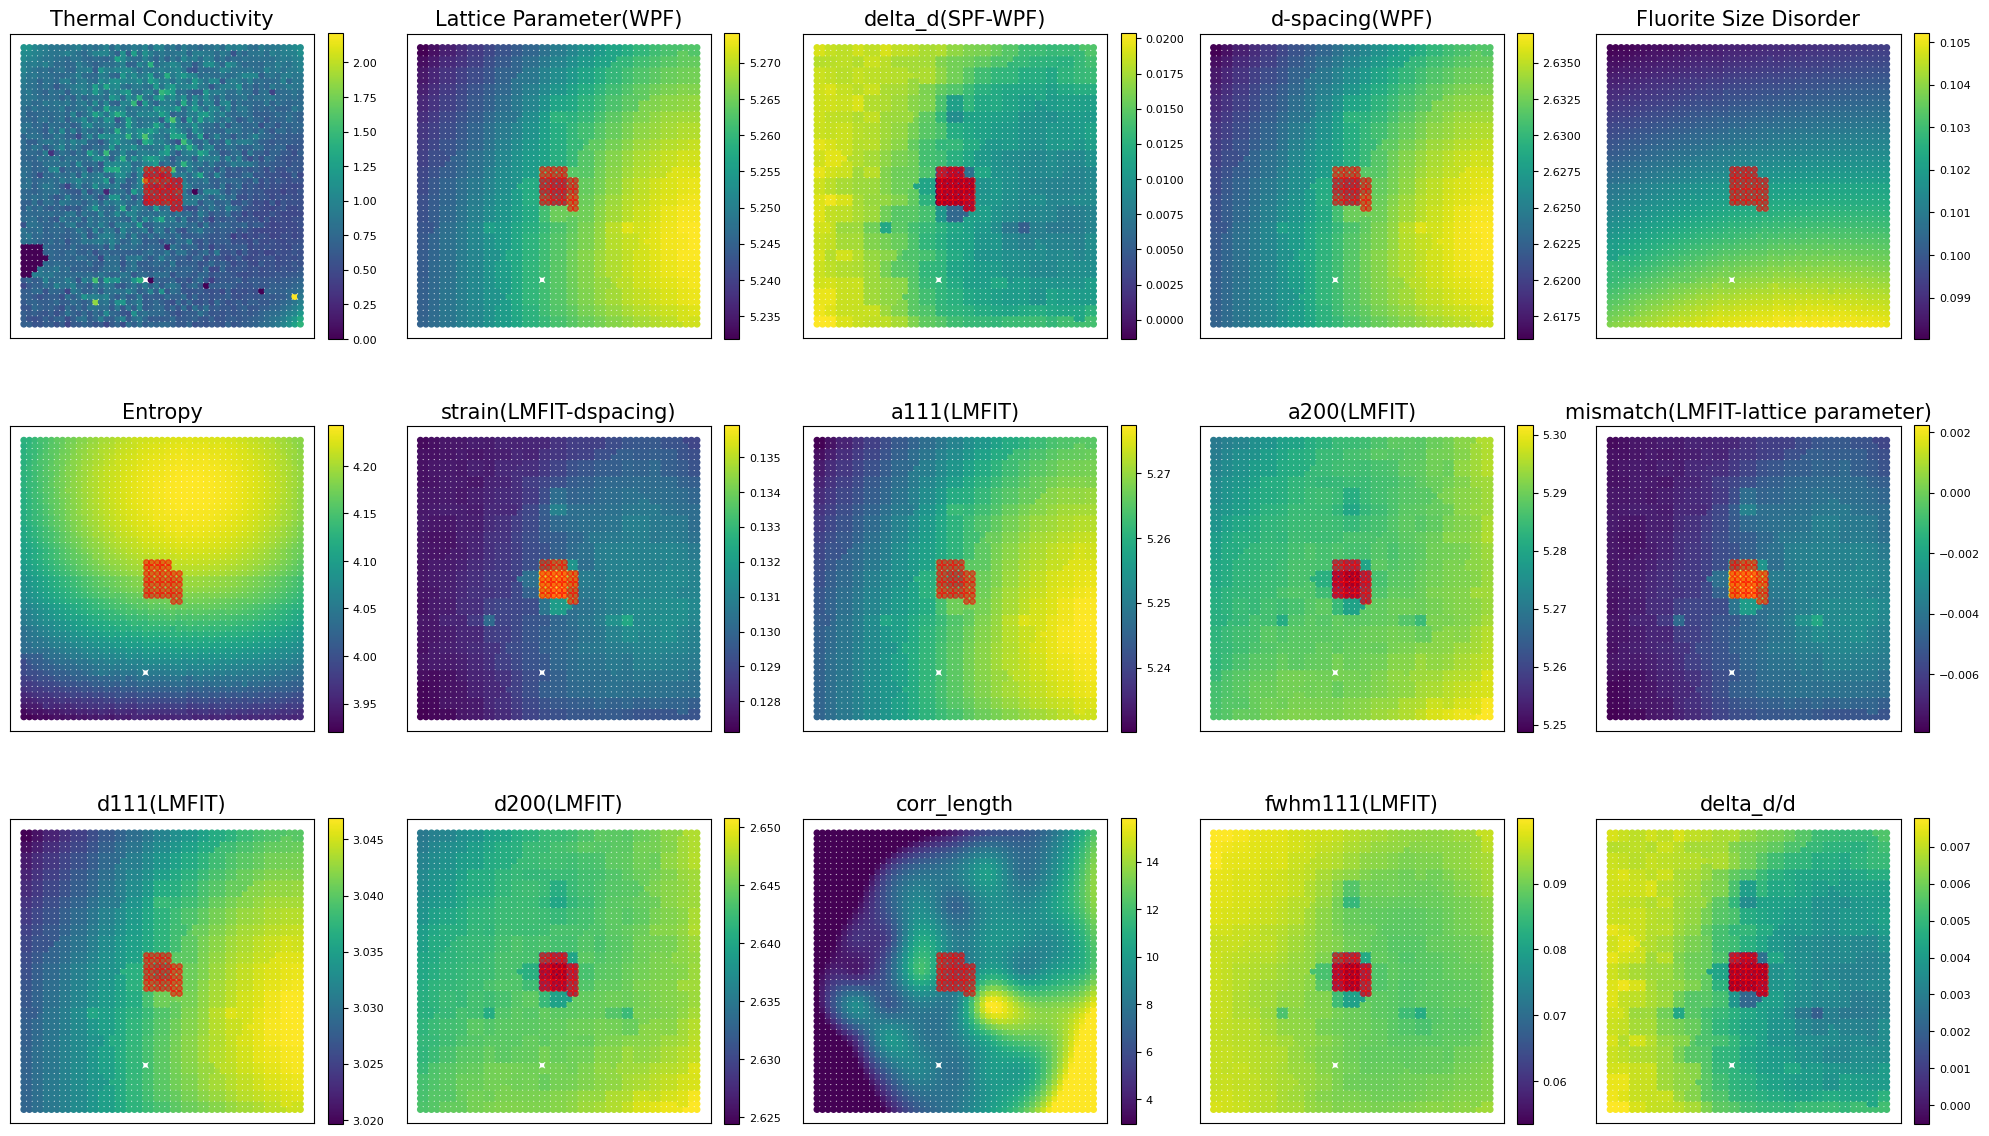

In [ ]:
x = df_clean["x"].to_numpy()
y = df_clean["y"].to_numpy()

feature_cols = [c for c in df_clean.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df_clean[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    ax.scatter(x[rows_to_drop], y[rows_to_drop], s=16, color="r", alpha=.5)

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()

## Fast model screening

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


def compare_models(df, target_column, random_state=42):
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Preprocessing pipeline
    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
    X_proc = preprocessor.fit_transform(X)

    scoring = {
        "r2": make_scorer(r2_score),
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "rmse":  make_scorer(rmse, greater_is_better=False)
    }

    models = {
        "Linear": LinearRegression(),
        "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5),
        "Lasso": LassoCV(alphas=np.logspace(-2, 2, 10), cv=5, max_iter=3000),
        "ElasticNet": ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, max_iter=3000),
        "RandomForest": RandomForestRegressor(n_estimators=100, random_state=random_state),
        "GradientBoost": GradientBoostingRegressor(n_estimators=100, random_state=random_state)
    }


    results = {}
    for name, model in models.items():
        r2_scores = cross_val_score(model, X_proc, y, cv=5, scoring=scoring['r2'])
        mae_scores = cross_val_score(model, X_proc, y, cv=5, scoring=scoring['mae'])
        rmse_scores = cross_val_score(model, X_proc, y, cv=5, scoring=scoring['rmse'])

        results[name] = {
            "R² mean": np.mean(r2_scores),
            "R² std": np.std(r2_scores),
            "MAE mean": -np.mean(mae_scores),   # Negated to show as positive error
            "RMSE mean": -np.mean(rmse_scores)  # Negated to show as positive error
        }

    results_df = pd.DataFrame(results).T.sort_values("R² mean", ascending=False)
    return results_df


In [ ]:
#with region of anomaly
results_with = compare_models(df_clean, target, random_state=42)

In [ ]:
results_with

,R² mean,R² std,MAE mean,RMSE mean
GradientBoost,0.157234,0.142047,0.111382,0.028429
RandomForest,0.118518,0.179704,0.116849,0.029777
Linear,0.066605,0.166156,0.116504,0.031140
Ridge,-0.014453,0.229870,0.122918,0.033956
ElasticNet,-0.020671,0.233571,0.123004,0.034131
Lasso,-0.348684,0.263924,0.158430,0.045228


In [ ]:
#without region of anomaly
results_without = compare_models(df_clean1, target, random_state=42)

In [ ]:
results_without

,R² mean,R² std,MAE mean,RMSE mean
RandomForest,0.176341,0.134659,0.111919,0.027084
GradientBoost,0.170356,0.143471,0.110771,0.027280
Linear,0.079684,0.161684,0.113789,0.030006
Ridge,-0.004851,0.213658,0.121091,0.032904
ElasticNet,-0.013435,0.217465,0.121522,0.033191
Lasso,-0.300381,0.247339,0.153931,0.042470


# lets go with the random forest

In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

# --- robust RMSE scorer (works across sklearn versions) ---
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def tune_random_forest(
    df: pd.DataFrame,
    target_column: str,
    n_iter: int = 40,
    cv: int = 5,
    random_state: int = 42,
    n_jobs: int = -1
):
    """
    Random Forest hyperparameter optimization via RandomizedSearchCV.
    Returns (best_estimator, best_params, results_dataframe).

    Notes:
      - Trees don't need scaling; we only impute missing values.
      - Uses R² for selection; you can switch scoring below if you prefer RMSE/MAE.
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(random_state=random_state))
    ])

    # Parameter distributions (sane ranges for 2.6k x 17)
    param_distributions = {
        "rf__n_estimators": np.random.randint(150, 600, size=200),   # # of trees
        "rf__max_depth": [None] + list(np.random.randint(3, 30, size=28)),
        "rf__min_samples_split": np.random.randint(2, 21, size=20),
        "rf__min_samples_leaf": np.random.randint(1, 11, size=10),
        "rf__max_features": ["sqrt", "log2", 0.4, 0.6, 0.8],
        "rf__bootstrap": [True, False]
    }

    # Primary scorer for model selection; extras for reporting
    primary_scorer = make_scorer(r2_score)
    extra_scorers = {
        "r2": make_scorer(r2_score),
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "rmse": make_scorer(rmse, greater_is_better=False),
    }

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=primary_scorer,   # choose 'rmse' or 'mae' if you prefer
        cv=cv,
        refit=True,               # refit on full data using best params (by primary scorer)
        n_jobs=n_jobs,
        random_state=random_state,
        return_train_score=False,
        verbose=1
    )

    search.fit(X, y)

    # Build a readable results table with R² / MAE / RMSE
    cv_results = pd.DataFrame(search.cv_results_)
    # If you want MAE/RMSE from the same run, run multi-metric search; here we add a quick post-CV eval:
    # Re-score the CV splits for extra metrics using best estimator (simple and fast for overview)
    # (For strict multi-metric CV, instantiate RandomizedSearchCV with scoring=extra_scorers and refit='r2')

    best_estimator = search.best_estimator_
    best_params = search.best_params_

    # Tidy view of top configurations by mean test score
    results_table = cv_results[[
        "rank_test_score", "mean_test_score", "std_test_score", "param_rf__n_estimators",
        "param_rf__max_depth", "param_rf__min_samples_split", "param_rf__min_samples_leaf",
        "param_rf__max_features", "param_rf__bootstrap"
    ]].sort_values("rank_test_score").rename(columns={
        "mean_test_score": "R2 (CV mean)",
        "std_test_score": "R2 (CV std)"
    }).reset_index(drop=True)

    return best_estimator, best_params, results_table


In [ ]:
res_rf = tune_random_forest(df_clean1, target)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [ ]:
best_params = {}

for k in res_rf[1]:
  best_params[k[4:]] = res_rf[1][k]

print(best_params)

{'n_estimators': np.int64(354), 'min_samples_split': np.int64(9), 'min_samples_leaf': np.int64(8), 'max_features': 'sqrt', 'max_depth': np.int64(26), 'bootstrap': True}


In [ ]:
def train_random_forest_best(
    df: pd.DataFrame,
    target_column: str,
    best_params: dict | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
    return_predictions: bool = True,
):
    """
    Build and train a RandomForestRegressor with best params (from tuning).
    Uses a simple preprocessing step (median imputation). Trees don't need scaling.

    Parameters
    ----------
    df : DataFrame
        Full dataset including target.
    target_column : str
        Name of the target column.
    best_params : dict | None
        Dict of best params (keys without the 'rf__' prefix). Examples:
            {
                "n_estimators": 400,
                "max_depth": 18,
                "min_samples_split": 5,
                "min_samples_leaf": 2,
                "max_features": "sqrt",
                "bootstrap": True
            }
        If None, defaults are used.
    test_size : float
        Test split fraction.
    random_state : int
        Random seed for reproducibility.
    return_predictions : bool
        If True, return (y_test, y_pred) as well.

    Returns
    -------
    model : Pipeline
        Fitted pipeline: [imputer] -> [rf].
    metrics : dict
        {"R2": ..., "MAE": ..., "RMSE": ...}
    preds (optional) : (y_test, y_pred)
        Only returned if return_predictions=True.
    """
    X = df.drop(columns=[target_column])
    y = df[target_column].values

    # Split once to report final metrics
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Build RF with best params (or sane defaults)
    rf_kwargs = {"random_state": random_state}
    if best_params:
        rf_kwargs.update(best_params)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(**rf_kwargs))
    ])

    # Fit
    pipe.fit(X_train, y_train)

    # Evaluate
    y_pred = pipe.predict(X_test)
    metrics = {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5  # robust across sklearn versions
    }

    if return_predictions:
        return pipe, metrics, (y_test, y_pred)
    return pipe, metrics


In [ ]:
pipe, metrics, (y_test, y_pred) = train_random_forest_best(df_clean1, target, best_params=best_params)

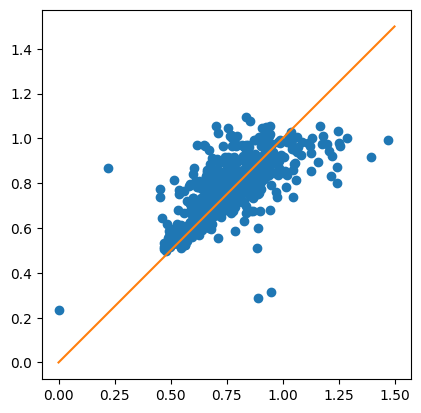

In [ ]:
plt.plot(y_test, y_pred, 'o')
plt.plot([0,1.5], [0,1.5])
plt.gca().set_aspect('equal')

In [ ]:
print(metrics)

{'R2': 0.4050592175866464, 'MAE': 0.09370700249859423, 'RMSE': 0.1307808649005705}


## shap

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def shap_report_for_rf_pipeline(
    fitted_pipeline,
    X_full: pd.DataFrame,
    top_k_dependence: int = 5,
    subsample: int = 1200,
    random_state: int = 42,
    show_plots: bool = True
):
    """
    SHAP analysis for a pipeline = [imputer] -> [rf].
    Returns a DataFrame with mean(|SHAP|) per feature (sorted desc)
    and the ordered feature list. Optionally shows summary/bar/dependence plots.

    Parameters
    ----------
    fitted_pipeline : sklearn Pipeline
        The pipeline returned by train_random_forest_best (imputer->rf).
    X_full : pd.DataFrame
        Feature dataframe used for training/evaluation (no target column).
    top_k_dependence : int
        How many top features to show with dependence plots.
    subsample : int
        Max rows to use for SHAP (speed/memory). If None, use all rows.
    random_state : int
        For reproducible subsampling.
    show_plots : bool
        If True, display SHAP plots.

    Returns
    -------
    shap_df : pd.DataFrame
        Columns: ["feature", "mean_abs_shap"], sorted by importance.
    top_features : list[str]
        Names of features ordered by importance.
    """

    # --- Extract pieces from pipeline ---
    # imputer won't change feature order/names
    rf = fitted_pipeline.named_steps.get("rf", None)
    if rf is None:
        raise ValueError("Pipeline must contain a step named 'rf' (RandomForestRegressor).")

    imputer = fitted_pipeline.named_steps.get("imputer", None)
    if imputer is None:
        raise ValueError("Pipeline must contain a step named 'imputer'.")

    # --- Transform X with the same imputer used in the pipeline ---
    # (fit has already happened on the pipeline)
    X_imputed = imputer.transform(X_full)
    # Keep feature names for SHAP plots & importance table
    feature_names = list(X_full.columns)

    # --- Subsample for SHAP speed if needed ---
    if subsample is not None and X_imputed.shape[0] > subsample:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(X_imputed.shape[0], size=subsample, replace=False)
        X_shap = X_imputed[idx]
        X_display = X_full.iloc[idx].reset_index(drop=True)
    else:
        X_shap = X_imputed
        X_display = X_full.reset_index(drop=True)

    # --- Build SHAP explainer for tree models ---
    # TreeExplainer is fastest/most accurate for RandomForest
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_shap)

    # For regressors, shap_values is (n_samples, n_features)
    # Compute global importance = mean(|SHAP|) per feature
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    top_features = shap_df["feature"].tolist()

    if show_plots:
        # Summary (beeswarm): distribution of SHAP per feature
        shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names, show=True)

        # Bar plot of mean(|SHAP|)
        shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names,
                          plot_type="bar", show=True)

        # Dependence plots for top-k features (color by strongest interacting feature automatically)
        for f in shap_df["feature"].head(top_k_dependence):
            shap.dependence_plot(
                f, shap_values, X_shap, feature_names=feature_names, show=True
            )

    return shap_df, top_features


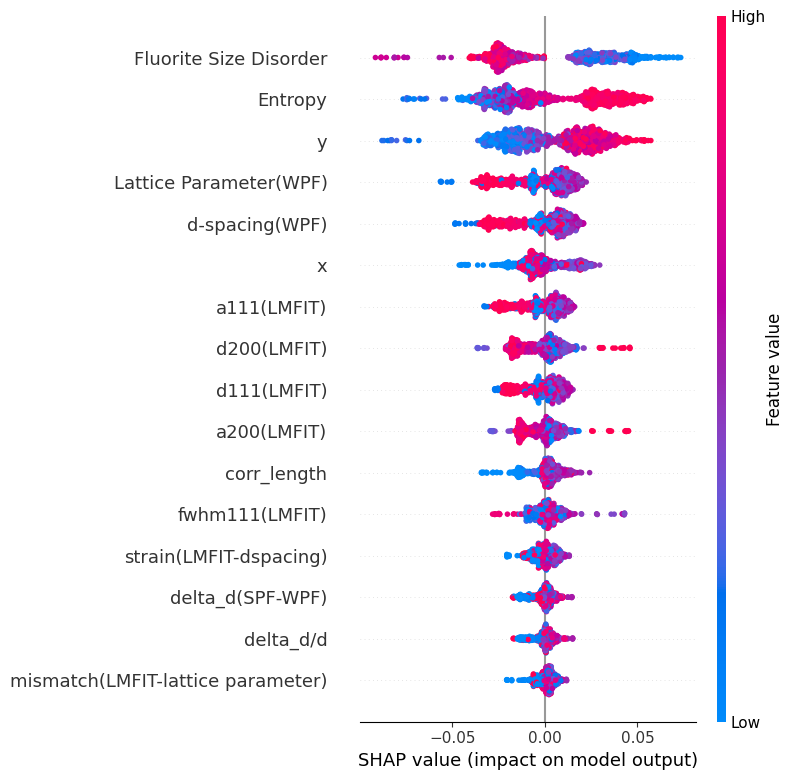

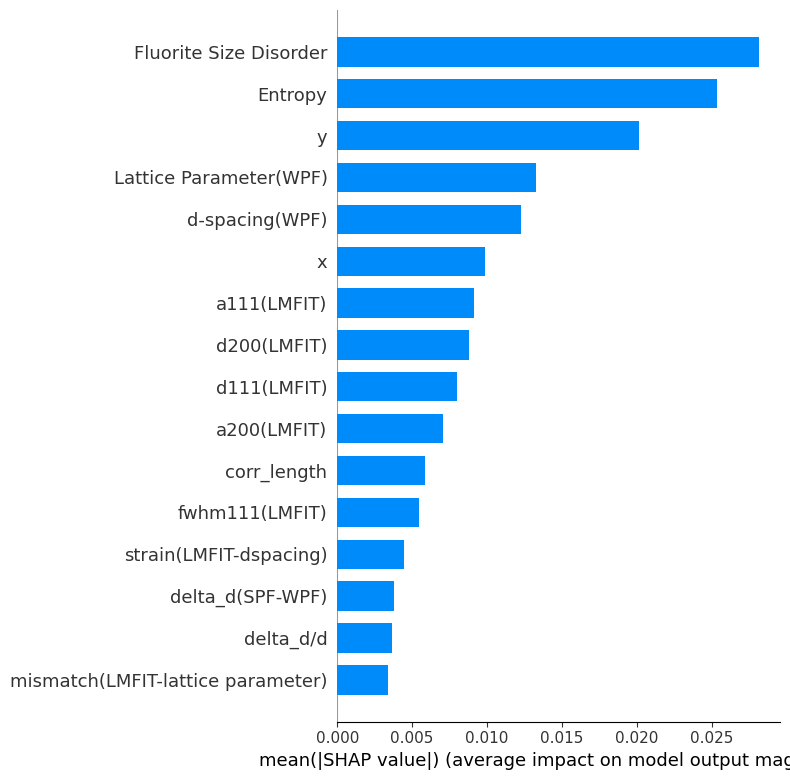

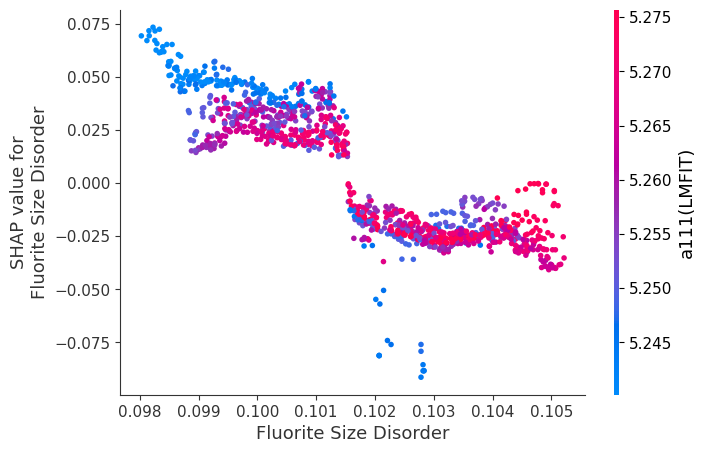

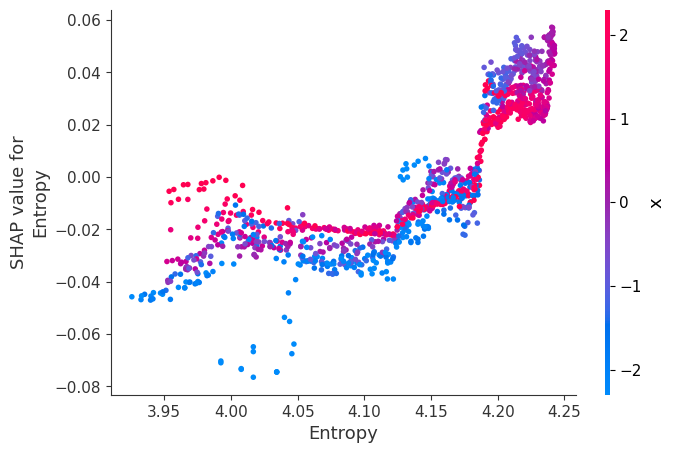

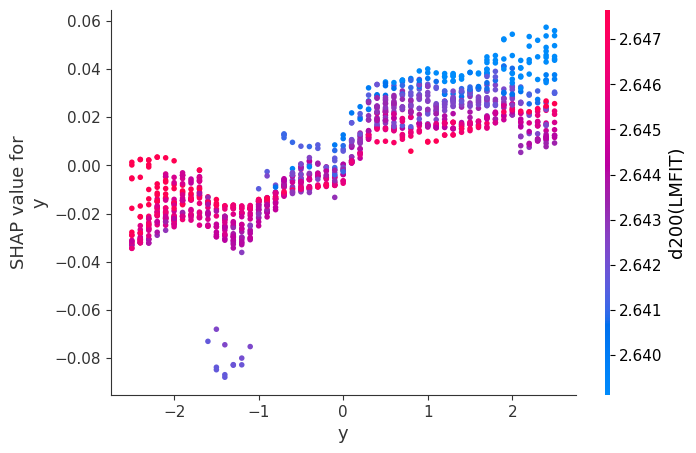

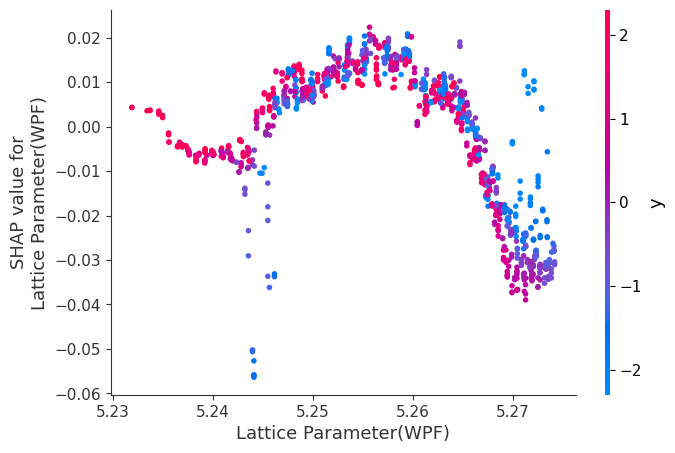

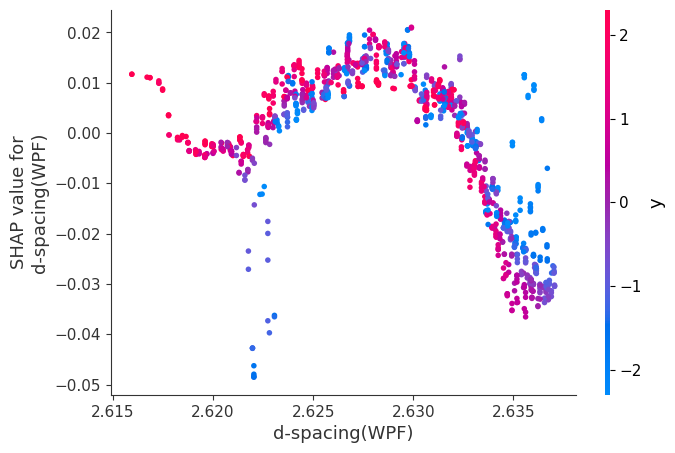

In [ ]:
# defining most important features
shap_df, top_features = shap_report_for_rf_pipeline(pipe, df_clean1.drop(columns=[target]) )

In [ ]:
df_clean2 = df_clean1[[*top_features[:6], target]]

In [ ]:
pipe2, metrics2, (y_test2, y_pred2) = train_random_forest_best(df_clean2, target, best_params=best_params)

In [ ]:
metrics2

{'R2': 0.4054338727844342,
 'MAE': 0.09406458252393311,
 'RMSE': 0.13073967975359077}

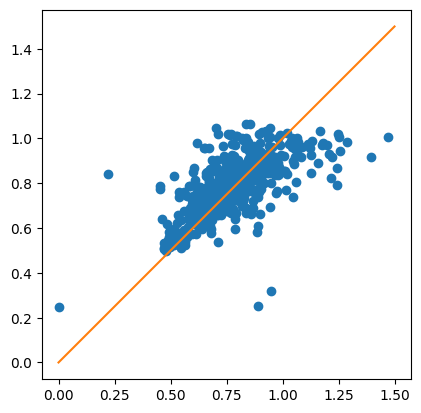

In [ ]:
plt.plot(y_test2, y_pred2, 'o')
plt.plot([0,1.5], [0,1.5])
plt.gca().set_aspect('equal')

In [ ]:
#define parameter number on the model efficiency

r2, mae, rmse = np.array([]), np.array([]), np.array([])


for i in range(2, 10):

  df_clean2 = df_clean1[[*top_features[:i], target]]
  pipe2, metrics2, (y_test2, y_pred2) = train_random_forest_best(df_clean2, target, best_params=best_params)

  r2 = np.append(r2, metrics2['R2'])
  mae = np.append(mae, metrics2['MAE'])
  rmse = np.append(rmse, metrics2['RMSE'])

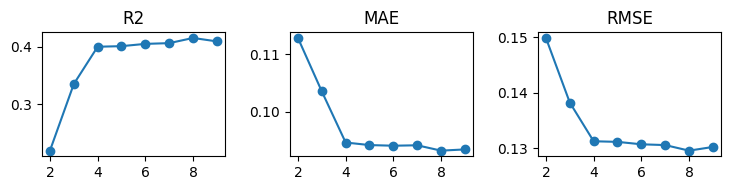

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(7.5, 2))

ax[0].plot(np.arange(2,10), r2, 'o-')
ax[1].plot(np.arange(2,10), mae, 'o-')
ax[2].plot(np.arange(2,10), rmse, 'o-')

ax[0].set_title('R2')
ax[1].set_title('MAE')
ax[2].set_title('RMSE')

plt.tight_layout()

In [ ]:
print(f'Most important features: {top_features[:3]}')

Most important features: ['Fluorite Size Disorder', 'Entropy', 'y']
